In [2]:
import pandas as pd
import os

In [3]:
os.getcwd()

'/Users/selewaut/Code Projects/master/dm2026b'

In [4]:
experimento = "HT29003"

In [5]:
gridsearch_df = pd.read_csv(f"exp/{experimento}/gridsearch_detalle.txt", sep='\t')

In [13]:
gridsearch_df[gridsearch_df["cp"] >= 0].sort_values(by="ganancia_test", ascending=False)

,semilla,cp,maxdepth,minsplit,minbucket,ganancia_test
1,644857,1.000000e-11,6,150,30,0.0
231,644857,1.000000e-11,14,270,68,0.0
215,644857,1.000000e-11,14,210,70,0.0
217,644857,1.000000e-11,14,230,46,0.0
219,644857,1.000000e-11,14,230,58,0.0
...,...,...,...,...,...,...
115,644857,1.000000e-11,10,210,42,0.0
117,644857,1.000000e-11,10,210,52,0.0
119,644857,1.000000e-11,10,210,70,0.0
121,644857,1.000000e-11,10,230,46,0.0


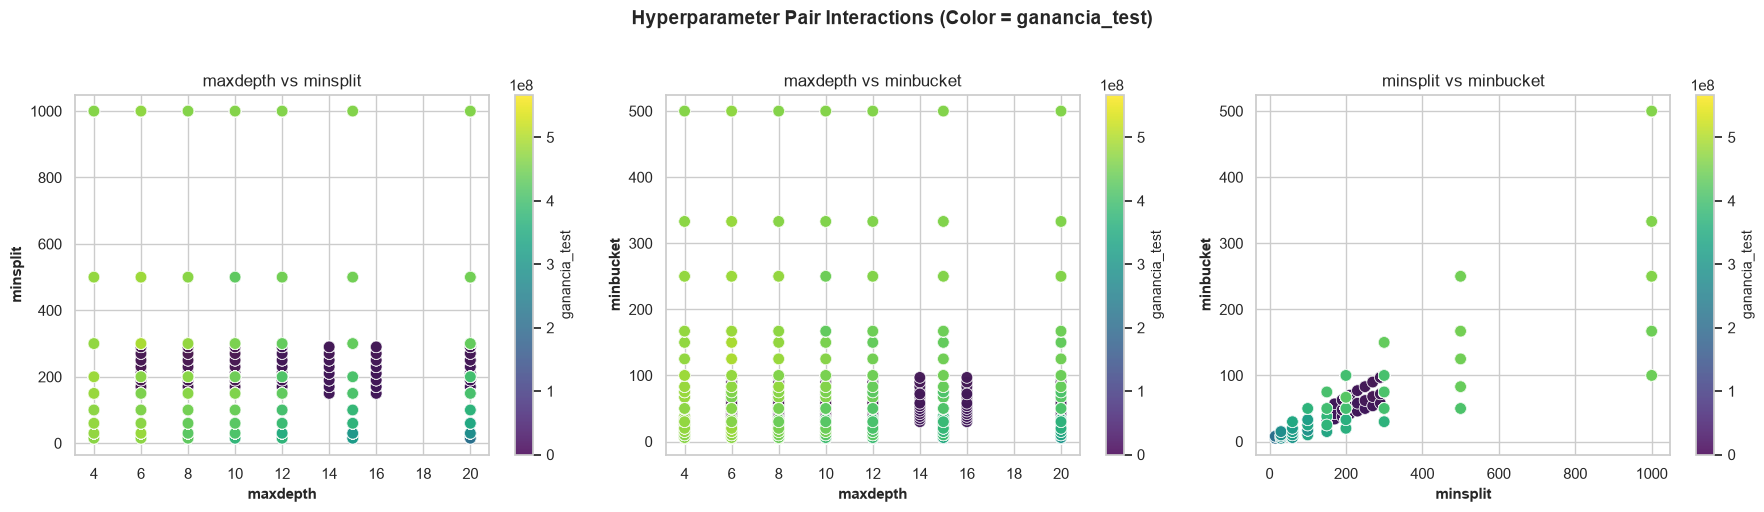

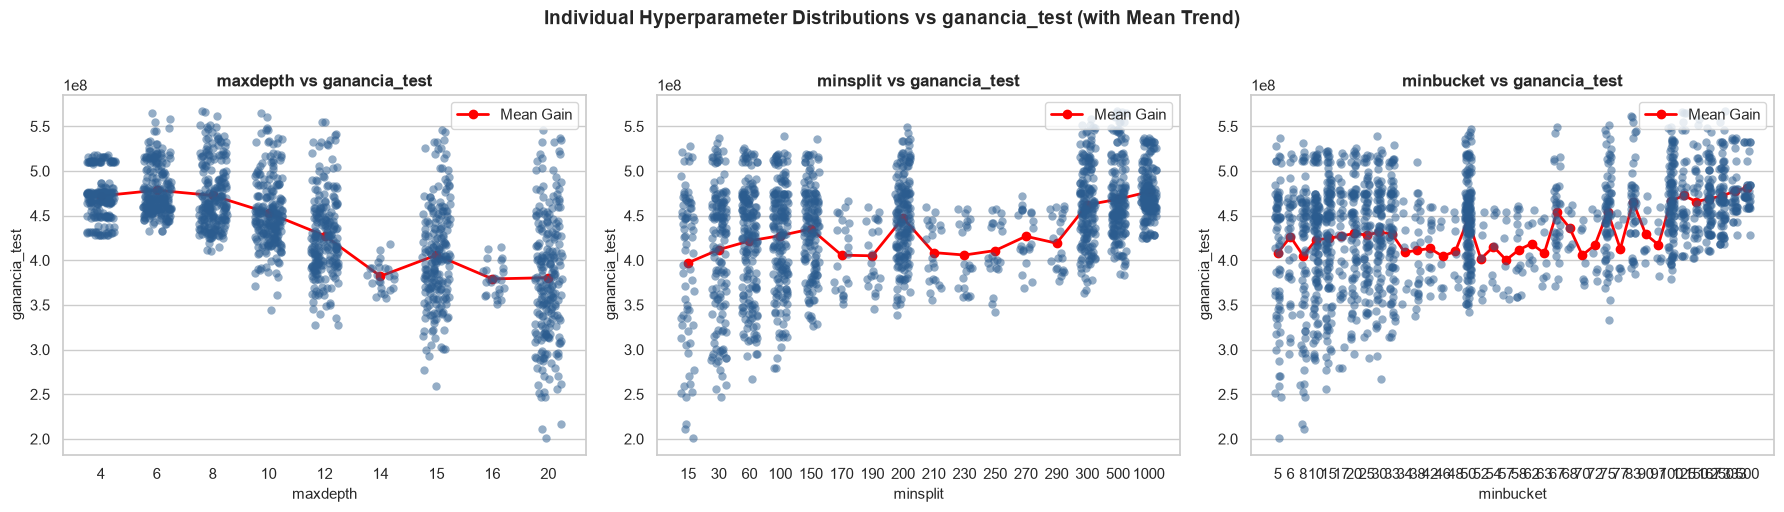

In [14]:
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

params = ["maxdepth", "minsplit", "minbucket"]
target = "ganancia_test"

# Set style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. 2D Scatter Plots for Hyperparameter Pairs (Hue = ganancia_test)
# ==========================================
pairs = list(itertools.combinations(params, 2))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (param_x, param_y) in zip(axes, pairs):
    sc = ax.scatter(
        gridsearch_df[param_x],
        gridsearch_df[param_y],
        c=gridsearch_df[target],
        cmap="viridis",
        s=70,
        edgecolors="w",
        linewidth=0.5,
        alpha=0.85,
    )
    ax.set_xlabel(param_x, fontsize=11, fontweight="bold")
    ax.set_ylabel(param_y, fontsize=11, fontweight="bold")
    ax.set_title(f"{param_x} vs {param_y}", fontsize=12)
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(target, fontsize=10)

plt.suptitle(
    "Hyperparameter Pair Interactions (Color = ganancia_test)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

# ==========================================
# 2. Individual Hyperparameter Scatter Plots vs ganancia_test
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# filter 0 ganancia cases
gridsearch_df = gridsearch_df[gridsearch_df.ganancia_test != 0]
# Top 5% threshold to highlight best configurations
top_threshold = gridsearch_df[target].quantile(0.95)

for ax, param in zip(axes, params):
    # Scatter plot with slight jitter for discrete hyperparameter values
    sns.stripplot(
        data=gridsearch_df,
        x=param,
        y=target,
        ax=ax,
        jitter=0.25,
        alpha=0.5,
        color="#2b5c8f",
        size=6,
    )

    # Trendline showing mean ganancia_test per hyperparameter level
    means = gridsearch_df.groupby(param)[target].mean().reset_index()
    ax.plot(
        range(len(means)),
        means[target],
        color="red",
        marker="o",
        linewidth=2,
        label="Mean Gain",
    )

    ax.set_title(f"{param} vs {target}", fontsize=12, fontweight="bold")
    ax.set_xlabel(param, fontsize=11)
    ax.set_ylabel(target, fontsize=11)
    ax.legend(loc="upper right")

plt.suptitle(
    "Individual Hyperparameter Distributions vs ganancia_test (with Mean Trend)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

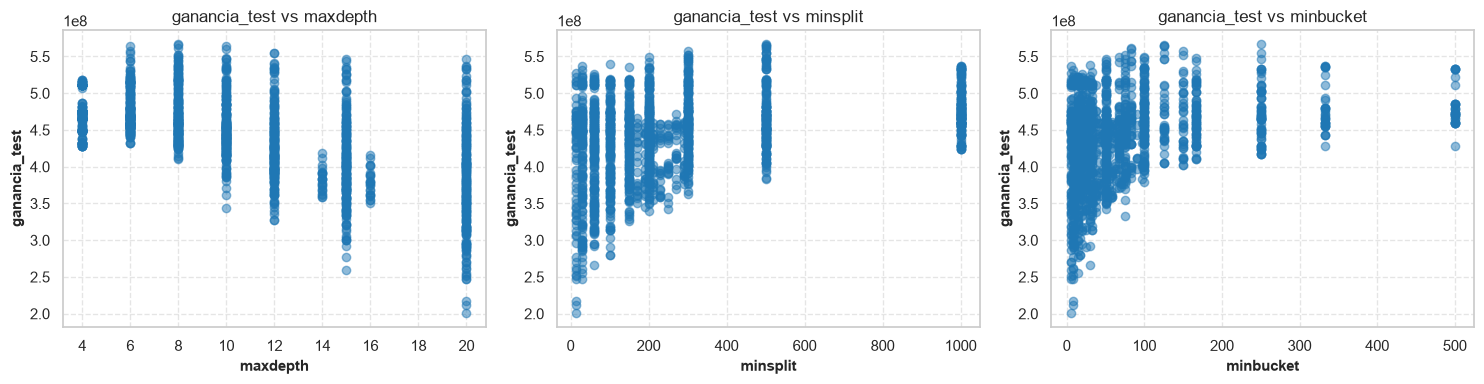

In [15]:
import matplotlib.pyplot as plt

params = ["maxdepth", "minsplit", "minbucket"]
target = "ganancia_test"

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, param in zip(axes, params):
    ax.scatter(gridsearch_df[param], gridsearch_df[target], alpha=0.5, color="#1f77b4")
    ax.set_xlabel(param, fontsize=11, fontweight="bold")
    ax.set_ylabel(target, fontsize=11, fontweight="bold")
    ax.set_title(f"{target} vs {param}")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [6]:
gridsearch_df = pd.read_csv(f"exp/{experimento}/gridsearch_detalle.txt", sep='\t')
gridsearch_df  = gridsearch_df.sort_values(by="ganancia_test", ascending=False).reset_index(drop=True)

# gridsearch_df.reset_index(inplace=True)

In [7]:
gridsearch_df

,semilla,cp,maxdepth,minsplit,minbucket,ganancia_test
0,218249,-1.000000e+00,8,500,250,5.670833e+08
1,218249,-1.000000e+00,8,500,125,5.659167e+08
2,218249,-1.000000e+00,10,500,125,5.648333e+08
3,218249,-1.000000e+00,6,500,125,5.644167e+08
4,218249,-1.000000e+00,8,500,83,5.615833e+08
...,...,...,...,...,...,...
1716,644857,1.000000e-11,12,150,30,0.000000e+00
1717,644857,1.000000e-11,16,170,34,0.000000e+00
1718,644857,1.000000e-11,10,210,52,0.000000e+00
1719,644857,1.000000e-11,8,230,58,0.000000e+00


In [8]:
gridsearch_df.iloc[[1, 2, 5, 10, 50, 100]].iloc[:, -1].to_clipboard()

In [ ]:
	ganancia_test
1	565916666.666667
2	564833333.333333
5	560500000.0
10	552000000.0
50	532333333.333333
100	518083333.333333


IndentationError: unexpected indent (1183618087.py, line 1)

In [ ]:
	semilla	cp	maxdepth	minsplit	minbucket	ganancia_test
1	218249	-1.0	8	500	125	565916666.666667
2	218249	-1.0	10	500	125	564833333.333333
5	218249	-1.0	10	500	83	560500000.0
10	218249	-1.0	8	300	150	552000000.0
50	218249	-1.0	8	1000	100	532333333.333333
100	218249	-1.0	4	100	50	518083333.333333


In [ ]:
gridsearch_df.semilla.unique()


array([644857, 218249, 493747, 655103, 169327])

In [23]:
# Returns True if ALL rows are unique, False if there are duplicate rows
all_unique = not gridsearch_df.duplicated().any()
print(all_unique)

True
